Data komentar (query + text)

↓
Preprocessing teks (cleaning, stopword, dll)

↓
Pelabelan sentimen (Positif / Negatif / Netral)  ← perlu dilakukan manual/semi-otomatis

↓
Training model deep learning (LSTM / IndoBERT)

↓
Evaluasi akurasi training & testing set

## #1 Preprocessing Data
Memulai pemrosesan data untuk youtube_dataset.json


In [1]:
import pandas as pd
import numpy as np
import json
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import emoji


In [73]:
# Load data
with open("youtube_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Jadikan DataFrame dan ambil hanya kolom query + text
df = pd.DataFrame(data)[["query", "text"]]

In [4]:
# cek apakah ada baris kosong
print(df[df["text"].str.strip() == ""])

df.isnull().sum()

Empty DataFrame
Columns: [query, text]
Index: []


query    0
text     0
dtype: int64

In [3]:
# 
df = df.reset_index(drop=True)

print(f"Total data: {len(df)}")
print(df.head())

Total data: 82509
                      query                                               text
0  korban menjadi tersangka  Sudah jelas ya. Penegak hukum,polisi,Jaksa,hak...
1  korban menjadi tersangka                     parah nya hukum Indonesia😂😂😂😂😂
2  korban menjadi tersangka  Hukum dan penegak hukum memang bajingan di neg...
3  korban menjadi tersangka          Parah sih emang penegak hukum negeri kita
4  korban menjadi tersangka      Rakyat indonesia sudah amat geram sama polisi


Teks Mentah → Cleaning → Case Folding → Normalisasi → Tokenisasi → Stopword Removal → Stemming → Teks Bersih

In [4]:
# Cleaning data
# def clean_emoji(text):
#     return emoji.replace_emoji(text, replace="")

def cleaning(text):
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r'http\S+|www\S+', '', text)      # hapus URL
    text = re.sub(r'@\w+', '', text)                # hapus mention
    text = re.sub(r'#\w+', '', text)                # hapus hashtag
    text = re.sub(r'\d+', '', text)                 # hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)             # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()        # normalisasi spasi
    # menghapus angka
    text = re.sub(r'\d+', '', text)
    return text

In [74]:
df["text_clean"] = df["text"].apply(cleaning)
# hapus kolom cleaned_text jika tidak diperlukan
# df = df.drop(columns=["cleaned_text"])
df.head()

,query,text,text_clean
0,korban menjadi tersangka,"Sudah jelas ya. Penegak hukum,polisi,Jaksa,hak...",Sudah jelas ya Penegak hukum polisi Jaksa haki...
1,korban menjadi tersangka,parah nya hukum Indonesia😂😂😂😂😂,parah nya hukum Indonesia
2,korban menjadi tersangka,Hukum dan penegak hukum memang bajingan di neg...,Hukum dan penegak hukum memang bajingan di neg...
3,korban menjadi tersangka,Parah sih emang penegak hukum negeri kita,Parah sih emang penegak hukum negeri kita
4,korban menjadi tersangka,Rakyat indonesia sudah amat geram sama polisi,Rakyat indonesia sudah amat geram sama polisi


In [34]:
# test emoji
print(emoji.replace_emoji("parah nya hukum Indonesia😂😂😂😂😂", replace=''))
print("parah nya hukum Indonesia😂😂😂😂😂")

parah nya hukum Indonesia
parah nya hukum Indonesia😂😂😂😂😂


In [75]:
# hapus kolom text jika tidak diperlukan
df = df.drop(columns=["text"])
df.head()

,query,text_clean
0,korban menjadi tersangka,Sudah jelas ya Penegak hukum polisi Jaksa haki...
1,korban menjadi tersangka,parah nya hukum Indonesia
2,korban menjadi tersangka,Hukum dan penegak hukum memang bajingan di neg...
3,korban menjadi tersangka,Parah sih emang penegak hukum negeri kita
4,korban menjadi tersangka,Rakyat indonesia sudah amat geram sama polisi


In [76]:
# case folding menjadi huruf kecil semua
def case_folding(text):
    return text.lower()

df["text_clean"] = df["text_clean"].apply(case_folding)
df.head()

,query,text_clean
0,korban menjadi tersangka,sudah jelas ya penegak hukum polisi jaksa haki...
1,korban menjadi tersangka,parah nya hukum indonesia
2,korban menjadi tersangka,hukum dan penegak hukum memang bajingan di neg...
3,korban menjadi tersangka,parah sih emang penegak hukum negeri kita
4,korban menjadi tersangka,rakyat indonesia sudah amat geram sama polisi


In [ ]:
# normalisasi kata tidak baku / slang

# mendownload normalisasi
# url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
# kamus_df = pd.read_csv(url)
# kamus_df.to_csv("colloquial-indonesian-lexicon-normalisasi.csv", index=False)


In [77]:
df_normalisasi = pd.read_csv("colloquial-indonesian-lexicon-normalisasi.csv")
df_normalisasi = df_normalisasi[["slang", "formal"]]
df_normalisasi.head()


,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [9]:
# Buat dictionary SEKALI di luar fungsi
normalization_dict = dict(zip(df_normalisasi["slang"], df_normalisasi["formal"]))
# menambahkan custom slang
custom_slang = {
    "tlh": "telah",
    "gk": "tidak",
    "ga": "tidak",
}
normalization_dict.update(custom_slang)
# print(normalization_dict)

# Fungsi cukup lookup per kata — jauh lebih cepat
def normalize_slang(text):
    words = text.split()
    words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(words)

In [78]:
df['text_clean'] = df['text_clean'].apply(normalize_slang)
df.head()
df['text_clean'][0]

'sudah jelas ya penegak hukum polisi jaksa hakim dan pengacara yang terbiasa membela kasus kejahatan mereka semua memanfaatka n sisi kelemahan dari undang dan pasal pelanggaran hukum mereka memeanfaatkan kalimat yang ada pada pasal undang pelanggaran hukum untuk menjerat balik pelapor jika di ketahui pelapor adalah orang yang berduit mungkin pengusaha menengah atau siapa saja yang dianggapnya dapat mereka peras jadi dalam kasus ini pembuat undang untuk pelaku kejahatan tidak benar membuat undng itu secara sempurna pembuat undangnya sudah jelas dan nyata mereka orang bodoh berotak picik dan akal sehat mereka telah hilang cacatnya undang dinegara ini adalah itu tadi pasal perundangan masih dapat di manfaatkan oleh mereka para hakim sableng jaksa gendeng polisi pangayom kejahatan dan juga termasuk pengacara yang spesialis membela pelaku kejahatan anehnya dpr tutup telinga mendengar hal ini apakah memang sudah habis sama sekali orang jujur di negeri ini apakah memang sudah tidak ada orang 

In [11]:
# Stopword removal - Menghapus kata-kata umum yang tidak memiliki makna penting
factory = StopWordRemoverFactory()

stopwords = set(factory.get_stop_words())

stopwords_tambahan = {
    'ya', 'yah', 'wah', 'loh', 'lah', 'dong', 'sih', 
    'nih', 'deh', 'kok', 'eh', 'ah', 'oh', 'kan'
}
stopwords.update(stopwords_tambahan)
jangan_hapus = {
    'tidak', 'bukan', 'belum', 'jangan', 
    'tanpa', 'hanya', 'cukup', 'masih', 'perlu', 
    'harus', 'boleh', 'mungkin', 'sebaiknya',
}
stopwords = stopwords - jangan_hapus

stopword_remover = factory.create_stop_word_remover()

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stopwords]
    return ' '.join(words)

In [79]:
df['text_clean'] = df['text_clean'].apply(remove_stopwords)
df.info()
df.head()
df['text_clean'][0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82509 entries, 0 to 82508
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query       82509 non-null  object
 1   text_clean  82509 non-null  object
dtypes: object(2)
memory usage: 1.3+ MB


'jelas penegak hukum polisi jaksa hakim pengacara terbiasa membela kasus kejahatan semua memanfaatka n sisi kelemahan undang pasal pelanggaran hukum memeanfaatkan kalimat pasal undang pelanggaran hukum menjerat balik pelapor ketahui pelapor orang berduit mungkin pengusaha menengah siapa dianggapnya peras jadi kasus pembuat undang pelaku kejahatan tidak benar membuat undng sempurna pembuat undangnya jelas nyata orang bodoh berotak picik akal sehat hilang cacatnya undang dinegara tadi pasal perundangan masih manfaatkan hakim sableng jaksa gendeng polisi pangayom kejahatan termasuk pengacara spesialis membela pelaku kejahatan anehnya dpr tutup telinga mendengar memang habis sama sekali orang jujur negeri memang tidak orang pandai cerdas negeri undang tidak pernah revisi disempurnakan tidak menjadi bumerang masyarakat meminta keadilan menjadi korban kejahatan'

⚠️ Catatan: Untuk deep learning (LSTM/BERT), stemming kadang tidak wajib bahkan bisa mengurangi akurasi. IndoBERT bekerja lebih baik tanpa stemming karena sudah memahami imbuhan. Stemming lebih berguna untuk TF-IDF + SVM/RF.

In [15]:
# Stemming - Mengubah kata berimbuhan ke kata dasar (stemming)

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

#### Stemming VS Lemmatization
sama-sama mirip.

#### Segmentasi Morfem (Subword Tokenization) (Word piece tokenization (Milik BERT))

In [65]:
# Tokenisasi - Memecah teks menjadi kata-kata atau token
def tokenization(text):
    # atau pakai NLTK:
    # from nltk.tokenize import word_tokenize
    return word_tokenize(text)

In [69]:
# ini tidak perlu dilakukan karena sudah dilakukan di tahap sebelumnya
# df["text_clean"] = df["text_clean"].apply(tokenization)
df.head()

,query,text_clean
0,korban menjadi tersangka,jelas penegak hukum polisi jaksa hakim pengaca...
1,korban menjadi tersangka,parah nya hukum indonesia
2,korban menjadi tersangka,hukum penegak hukum memang bajingan negeri
3,korban menjadi tersangka,parah memang penegak hukum negeri
4,korban menjadi tersangka,rakyat indonesia geram sama polisi


In [ ]:
# df['text_clean'] = df['text_clean'].apply(lambda x: ' '.join(x))

## #2 Labeling (Positif, Negatif, Netral)
karena ini analisis sentimen mas e

In [ ]:
# mendownload kamus inset label indonesia dahulu
# pos_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
# neg_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

# pos_df = pd.read_csv(pos_url, sep='\t', header=None, names=['word', 'score'])
# neg_df = pd.read_csv(neg_url, sep='\t', header=None, names=['word', 'score'])

# pos_df.to_csv("positive_inset_label.csv", index=False)
# neg_df.to_csv("negative_inset_label.csv", index=False)

In [14]:
# weight mulai dari -5 sampai +5, dengan 0 sebagai netral
df_positive = pd.read_csv("positive_inset_label.csv", header=0)
df_negative = pd.read_csv("negative_inset_label.csv", header=0)

# menghapus double header
df_positive = df_positive[df_positive["score"] != "weight"].reset_index(drop=True)
df_negative = df_negative[df_negative["score"] != "weight"].reset_index(drop=True)

df_positive["score"] = df_positive["score"].astype(int)
df_negative["score"] = df_negative["score"].astype(int)

# membuat dictionary untuk lookup cepat
dict_positive = dict(zip(
    df_positive["word"].str.lower(), 
    df_positive["score"]
))
dict_negative = dict(zip(
    df_negative["word"].str.lower(), 
    df_negative["score"]
))

In [15]:
print(type(df_positive["score"][0]))  # → str
print(df_positive["score"].unique())  # → '5'
df_positive.info()
print(df_positive[0:5])

<class 'numpy.int64'>
[3 2 1 4 5]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3609 entries, 0 to 3608
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   word    3609 non-null   object
 1   score   3609 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 56.5+ KB
        word  score
0        hai      3
1    merekam      2
2  ekstensif      3
3  paripurna      1
4     detail      2


In [80]:
def label_sentiment(text):
    words = text.split()
    skor = 0
    for word in words:
        # jika tidak ditemukan di kamus positif, ambil 0. Jika ditemukan, tambahkan skornya
        if word in dict_positive:
            skor += dict_positive[word] 
        elif word in dict_negative:
            skor += dict_negative[word] # by key value, 
        # print(f"Word: {word}, Skor Positif: {dict_positive.get(word, 0)}, Skor Negatif: {dict_negative.get(word, 0)}, Total Skor: {skor}")
    
    if skor > 0:
        return "positif"
    elif skor < 0:
        return "negatif"
    else:
        return "netral"


In [81]:
# test
df.head()
label_sentiment(df['text_clean'][0])

'positif'

In [82]:
# terapkan labeling
df['label'] = df['text_clean'].apply(label_sentiment)
df.head(20)

,query,text_clean,label
0,korban menjadi tersangka,jelas penegak hukum polisi jaksa hakim pengaca...,positif
1,korban menjadi tersangka,parah nya hukum indonesia,negatif
2,korban menjadi tersangka,hukum penegak hukum memang bajingan negeri,positif
3,korban menjadi tersangka,parah memang penegak hukum negeri,positif
4,korban menjadi tersangka,rakyat indonesia geram sama polisi,positif
5,korban menjadi tersangka,makin enggak byr etitut lebih rendah pengemis ...,negatif
6,korban menjadi tersangka,jadi maling kalo gebukin apa viralon lapor polisi,netral
7,korban menjadi tersangka,polisi cari uang masuk cara memeras,negatif
8,korban menjadi tersangka,buset sama viralkan terus,positif
9,korban menjadi tersangka,waduh belakang sering sekali korban jadi tersa...,positif


In [83]:
# Label encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# cek mapping label
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# y = df['label_encoded'].values

{'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


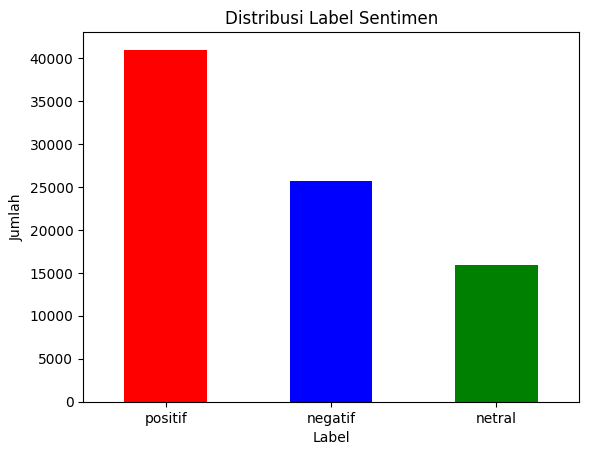

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# pengecekan distribusi label
df['label'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Distribusi Label Sentimen")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

Ada masalah distribusi yang tidak seimbang

|Teknik	                        |Kelebihan	                    |Kekurangan                     |
|-------------------------------|-------------------------------|-------------------------------|
|Undersampling positif	        |Cepat, sederhana	            |Buang data berharga            |
|Oversampling netral (SMOTE)	|Tidak buang data	            |Data sintetis bisa noise       |
|Class Weighting	            |Tidak ubah data sama sekali	|Hanya ubah bobot loss function |

masuk akal memakai class weighting


In [139]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
print("Kelas yang ada:", classes)

weight_class = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y
)

class_weight_dict = dict(zip(classes, weight_class))
print("Class weights:", class_weight_dict)

Kelas yang ada: [0 1 2]
Class weights: {np.int64(0): np.float64(1.168401376439101), np.int64(1): np.float64(1.6822435622973881), np.int64(2): np.float64(0.645292226836536)}


Nanti dipakai saat training LSTM:  
model.fit(X_train, y_train, class_weight=class_weight_dict, ...)

#### Namun karena kita butuh training cepat, kita akan kurangi datanya
ternyata padding membutuhkan data yang lebih ideal dari pada sebuah data asli yang banyak noise

In [102]:
# mengecek distribusi panjang teks
# lengths = pd.Series([len(seq) for seq in sequences])

# for min_kata in [2, 3, 4, 5, 6, 7, 8, 15]:
#     jumlah = (lengths >= min_kata).sum()
#     presentase = jumlah / len(lengths) * 100
#     print(f"Jumlah teks dengan panjang >= {min_kata} kata: {jumlah} ({presentase:.2f}%)")
    
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Hitung frekuensi tiap panjang teks
df['text_len'] = df['text_clean'].apply(lambda x: len(x.split()))
print(df['text_len'].describe())

# hapus yang memiliki jumlah 0 kata di teks
df_diluar = df[df["text_len"] != 0]

print(df_diluar['text_len'].describe())

count    82509.000000
mean        10.259729
std         15.563078
min          0.000000
25%          4.000000
50%          7.000000
75%         12.000000
max       1054.000000
Name: text_len, dtype: float64
count    81080.000000
mean        10.440553
std         15.639386
min          1.000000
25%          4.000000
50%          7.000000
75%         12.000000
max       1054.000000
Name: text_len, dtype: float64


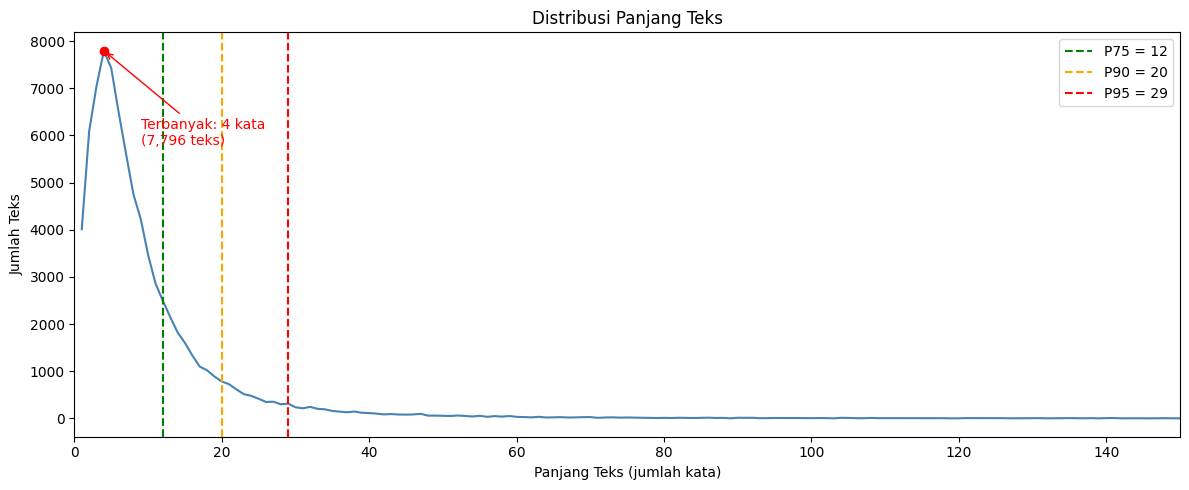

In [103]:
freq = df_diluar['text_len'].value_counts().sort_index()

peak_len   = freq.idxmax()
peak_count = freq.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(freq.index, freq.values, 
        color='steelblue', linewidth=1.5)

# Titik puncak
ax.scatter(peak_len, peak_count, color='red', zorder=5)
ax.annotate(f'Terbanyak: {peak_len} kata\n({peak_count:,} teks)',
            xy=(peak_len, peak_count),
            xytext=(peak_len + 5, peak_count - 2000),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

# Garis persentil
p75  = np.percentile(df['text_len'], 75)
p90  = np.percentile(df['text_len'], 90)
p95  = np.percentile(df['text_len'], 95)

ax.axvline(p75,  color='green',  linestyle='--', linewidth=1.5, label=f'P75 = {p75:.0f}')
ax.axvline(p90,  color='orange', linestyle='--', linewidth=1.5, label=f'P90 = {p90:.0f}')
ax.axvline(p95,  color='red',    linestyle='--', linewidth=1.5, label=f'P95 = {p95:.0f}')

ax.set_xlabel('Panjang Teks (jumlah kata)')
ax.set_ylabel('Jumlah Teks')
ax.set_title('Distribusi Panjang Teks')
ax.set_xlim(0, 150)   # batasi x agar outlier tidak merusak tampilan
ax.legend()
plt.tight_layout()
plt.show()

In [109]:
# mencari jumlah teks dengan panjang >= 38 kata dan <= 45 kata
lengths = df['text_len'].tolist()

jumlah_teks = sum(1 for length in lengths if 7 <= length <= 10)
print(f"Jumlah teks dengan panjang antara 38 dan 45 kata: {jumlah_teks}")

Jumlah teks dengan panjang antara 38 dan 45 kata: 18068


In [165]:
# memfilter teks dengan panjang antara 18 dan 33 kata
df_filtered = df[(df['text_len'] >= 7) & (df['text_len'] <= 10)].reset_index(drop=True)
print(f"Jumlah teks setelah filter: {len(df_filtered)}")

# suffle data
df_filtered = df_filtered.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_filtered.head())

Jumlah teks setelah filter: 18068
                      query  \
0            belajar coding   
1  korban menjadi tersangka   
2              membuat roti   
3            belajar coding   
4            belajar coding   

                                          text_clean    label  label_encoded  \
0      gue enggak muncul bang enggak mau run nodenya  positif              2   
1           makin lawak anjir apa cok sistem apa woy  negatif              0   
2  kalo tepung nya cukup tepung cakra kembar tida...  negatif              0   
3                  omg yes now i cannot learn python  positif              2   
4    iyya gan sama tinggal download vscode versi mac  positif              2   

   text_len  
0         8  
1         8  
2         9  
3         7  
4         8  


In [ ]:
# TIDAK JADI MEMAKAI SAMPLING PAKSA
TARGET = 9000  # ganti ke 20000 jika ingin lebih banyak

# Sample tiap kelas sesuai target
df_balanced = df.groupby('label').apply(
    lambda x: x.sample(
        n=min(TARGET, len(x)), 
        random_state=42
    )
).reset_index(drop=True)

# Shuffle data agar tidak terurut per label
df_balanced = df_balanced.sample(
    frac=1, 
    random_state=42
).reset_index(drop=True)

# Cek hasil
print(df_balanced['label'].value_counts())
print(f"Total data: {len(df_balanced)}")

label
negatif    9000
positif    9000
netral     9000
Name: count, dtype: int64
Total data: 27000


C:\Users\andre\AppData\Local\Temp\ipykernel_13052\4190833018.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('label').apply(


Teks Mentah  
    ↓  Cleaning          (masih string)  
    ↓  Case Folding       (masih string)  
    ↓  Normalisasi slang  (pakai .split() internal, output string)  
    ↓  Stopword Removal   (masih string)  
    ↓  [Stemming]         (opsional, masih string)  
    ↓  Teks Bersih ✅     (string siap disimpan ke CSV)  
  
── Setelah semua data bersih ──  
    ↓  Tokenisasi Keras   (teks → urutan angka untuk input LSTM)  
    ↓  Padding            (samakan panjang semua urutan)  
    ↓  Masuk ke model LSTM

In [166]:
df_filtered.head() 
# 7 sampai 10 kata yang akan diproses lebih lanjut

,query,text_clean,label,label_encoded,text_len
0,belajar coding,gue enggak muncul bang enggak mau run nodenya,positif,2,8
1,korban menjadi tersangka,makin lawak anjir apa cok sistem apa woy,negatif,0,8
2,membuat roti,kalo tepung nya cukup tepung cakra kembar tida...,negatif,0,9
3,belajar coding,omg yes now i cannot learn python,positif,2,7
4,belajar coding,iyya gan sama tinggal download vscode versi mac,positif,2,8


In [112]:
# Cek apakah label sudah benar
print(df_filtered['label'].value_counts())
print(df_filtered['label_encoded'].value_counts())

# Pastikan mapping benar
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

label
positif    9336
negatif    6787
netral     1945
Name: count, dtype: int64
label_encoded
2    9336
0    6787
1    1945
Name: count, dtype: int64
{'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


In [167]:
# membuat tokenization sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 

# membuat tokenizer keras
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df_filtered['text_clean'])

# konversi teks ke urutan angka 
sequences = tokenizer.texts_to_sequences(df_filtered['text_clean'])

print("Contoh sebelum:", df_filtered['text_clean'][0])
print("Contoh sesudah:", sequences[0])
print("Ukuran vocab:", len(tokenizer.word_index)+1)

Contoh sebelum: gue enggak muncul bang enggak mau run nodenya
Contoh sesudah: [54, 5, 233, 8, 5, 16, 815, 7254]
Ukuran vocab: 17865


In [168]:
# menentukan max length untuk padding
# max_length = max(len(seq) for seq in sequences)
# lengths = [len(seq) for seq in sequences]
# print(f"persentil 75%: {np.percentile(lengths, 75):.0f}")
# print(f"persentil 90%: {np.percentile(lengths, 90):.0f}")
# print(f"persentil 95%: {np.percentile(lengths, 95):.0f}")

MAX_LENGTH = 10  # berdasarkan analisis sebelumnya, bisa disesuaikan dengan kebutuhan
print("Panjang maksimal:", MAX_LENGTH)  # berdasarkan analisis sebelumnya, bisa disesuaikan dengan kebutuhan

# padding sequence agar memiliki panjang yang sama
padded_sequences = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
print("Contoh padded:", padded_sequences[:5])
print("Shape padded:", padded_sequences.shape)

Panjang maksimal: 10
Contoh padded: [[  54    5  233    8    5   16  815 7254    0    0]
 [  93 1610  674   10 1726 1002   10 2331    0    0]
 [   9   61    2  570   61  511 1349    3   19    0]
 [1422  957  628   38 4898  365  174    0    0    0]
 [7255  675   15  375  876  661  587 1611    0    0]]
Shape padded: (18068, 10)


## #3 Splitting Data
melakukan splitting data sesuai case

In [206]:
from sklearn.model_selection import train_test_split

X = padded_sequences
y = df_filtered['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80/20
    random_state=42,
    stratify=y           # pastikan distribusi label seimbang di train & test
)

# X_test, X_val, y_test, y_val = train_test_split(
#     X_temp, y_temp,
#     test_size=0.5,       # 50/50 dari sisa 20% → 10% test, 10% val
#     random_state=42,
#     stratify=y_temp      # pastikan distribusi label seimbang di test & val
# )

print(f"\nData training : {X_train.shape}")
# print(f"Data validation: {X_val.shape}")
print(f"Data testing  : {X_test.shape}")


Data training : (14454, 10)
Data testing  : (3614, 10)


## #4 Modeling (Case 1 LSTM)

In [153]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
import numpy as np

In [212]:
import optuna
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, SpatialDropout1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

optuna.logging.set_verbosity(optuna.logging.WARNING)
MAX_LEN        = X_train.shape[1]
VOCAB_SIZE     = len(tokenizer.word_index) + 1
NUM_CLASSES    = 3

def objective(trial):
    K.clear_session()

    # Search space
    embedding_dim   = trial.suggest_categorical('embedding_dim', [16, 32, 64, 128])
    lstm_units      = trial.suggest_categorical('lstm_units', [16, 32, 64, 128])
    spatial_dropout = trial.suggest_float('spatial_dropout', 0.2, 0.5)
    lstm_dropout    = trial.suggest_float('lstm_dropout', 0.2, 0.5)
    dense_units     = trial.suggest_categorical('dense_units', [16, 32, 64])
    dense_dropout   = trial.suggest_float('dense_dropout', 0.2, 0.5)
    learning_rate   = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size      = trial.suggest_categorical('batch_size', [128, 256, 512])

    # Build model
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim),
        SpatialDropout1D(spatial_dropout),
        Bidirectional(LSTM(lstm_units, dropout=lstm_dropout, return_sequences=False)),
        Dense(dense_units, activation='relu'),
        Dropout(dense_dropout),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # ── Training ─────────────────────────────────────────────
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )

    # Return val_accuracy terbaik
    return max(history.history['val_accuracy'])

# ── Jalankan Study ───────────────────────────────────────────
study = optuna.create_study(direction='maximize')
study.optimize(
    objective, 
    n_trials=20, 
    show_progress_bar=True,
    # prune_after_trials=5  # tambahkan pruning untuk menghentikan trial yang buruk lebih awal
)

print("✅ Best val_accuracy :", study.best_value)
print("✅ Best params       :", study.best_params)

  0%|          | 0/20 [00:00<?, ?it/s]

✅ Best val_accuracy : 0.865145206451416
✅ Best params       : {'embedding_dim': 128, 'lstm_units': 16, 'spatial_dropout': 0.28541273736451245, 'lstm_dropout': 0.3615373545664077, 'dense_units': 16, 'dense_dropout': 0.4104182610040119, 'learning_rate': 0.008795254556840897, 'batch_size': 256}


In [213]:
K.clear_session()
best = study.best_params

model_best = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=best['embedding_dim']),
    SpatialDropout1D(best['spatial_dropout']),
    Bidirectional(LSTM(best['lstm_units'], dropout=best['lstm_dropout'])),
    Dense(best['dense_units'], activation='relu'),
    Dropout(best['dense_dropout']),
    Dense(NUM_CLASSES, activation='softmax')
])

model_best.compile(
    optimizer=Adam(learning_rate=best['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_best.fit(
    X_train, y_train,
    epochs=30,
    batch_size=best['batch_size'],
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_lstm_optuna.keras', monitor='val_loss', save_best_only=True)
    ],
    verbose=1
)

# Evaluasi
from sklearn.metrics import classification_report
y_pred = np.argmax(model_best.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['negatif', 'netral', 'positif']))
testing_accuracy = model_best.evaluate(X_test, y_test, verbose=0)[1]
print(f"✅ Testing Accuracy: {testing_accuracy:.4f}")

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.7210 - loss: 0.6762 - val_accuracy: 0.8154 - val_loss: 0.4591
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8717 - loss: 0.3507 - val_accuracy: 0.8548 - val_loss: 0.4140
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9191 - loss: 0.2252 - val_accuracy: 0.8548 - val_loss: 0.4762
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9409 - loss: 0.1684 - val_accuracy: 0.8499 - val_loss: 0.5781
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9502 - loss: 0.1385 - val_accuracy: 0.8409 - val_loss: 0.6159
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9583 - loss: 0.1175 - val_accuracy: 0.8402 - val_loss: 0.6393
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9676 - loss: 0.0951 - val_accuracy: 0.8299 - val_loss: 0.7783
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

     negatif  

In [ ]:
# Percobaan awal dengan parameter default (tanpa Optuna) untuk baseline
VOCAB_SIZE     = len(tokenizer.word_index) + 1   
EMBEDDING_DIM  = 128
NUM_CLASSES    = 3       # positif, negatif, netral
MAX_LEN        = X_train.shape[1]  # panjang sequence setelah padding

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,   # ↓ dari 128 → reduce overfit
    ),
    SpatialDropout1D(0.4),  # ↑ regularisasi
    LSTM(32, return_sequences=False),  # ↑ lebih informatif
    Dropout(0.5),  # ↑ lebih agresif
    Dense(16, activation='relu'),  # ↓ dari 32
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')  # 3 kelas
])

# model.summary()

In [175]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),  # bisa disesuaikan
    loss='sparse_categorical_crossentropy',  # karena label masih integer
    metrics=['accuracy']
)

In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    'balanced', 
    classes=classes, 
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,          
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model_lstm.keras',
    monitor='val_accuracy',
    save_best_only=True
)

# cek distribusi label di training set
print(np.bincount(y_train))

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# model.save("model_lstm_final.keras")

Class weights: {np.int64(0): np.float64(0.8874562534536747), np.int64(1): np.float64(3.096401028277635), np.int64(2): np.float64(0.6450662739322534)}
[5429 1556 7469]
Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4026 - loss: 1.0934 - val_accuracy: 0.6386 - val_loss: 1.0719
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6234 - loss: 0.9753 - val_accuracy: 0.7305 - val_loss: 0.7552
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7240 - loss: 0.7782 - val_accuracy: 0.7460 - val_loss: 0.6426
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7905 - loss: 0.6266 - val_accuracy: 0.7836 - val_loss: 0.5456
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8356 - loss: 0.5077 - val_accuracy: 0.7947 - val_loss: 0.5058
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8621 - loss: 0.4399 - val_accuracy: 0.8035 - val_loss: 0.4957
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accu

### Evaluasi Model


In [210]:
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi
y_pred = np.argmax(model.predict(X_test), axis=1)

# Akurasi training dan testing
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc   = model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")

# Laporan lengkap per kelas
label_names = ['negatif', 'netral', 'positif']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Training Accuracy : 0.9979 (99.79%)
Testing Accuracy  : 0.8099 (80.99%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.85      0.81      0.83      1358
      netral       0.50      0.46      0.48       389
     positif       0.84      0.89      0.86      1867

    accuracy                           0.81      3614
   macro avg       0.73      0.72      0.72      3614
weighted avg       0.81      0.81      0.81      3614



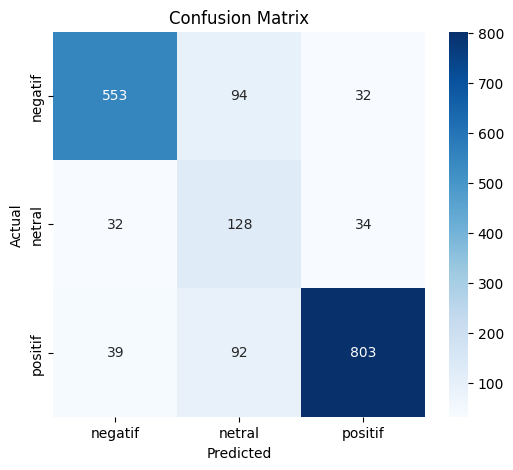

In [133]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## #5 Modeling (Case 2 CNN)

In [215]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=VOCAB_SIZE, 
        output_dim=128, 
    ),
    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_cnn = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

checkpoint_cnn = ModelCheckpoint(
    'best_model_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_cnn],
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5346 - loss: 1.0141 - val_accuracy: 0.6728 - val_loss: 0.7887
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7470 - loss: 0.7180 - val_accuracy: 0.8028 - val_loss: 0.5463
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8586 - loss: 0.4647 - val_accuracy: 0.7869 - val_loss: 0.5477
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9098 - loss: 0.3101 - val_accuracy: 0.7873 - val_loss: 0.5926
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9472 - loss: 0.1919 - val_accuracy: 0.7932 - val_loss: 0.6767
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9648 - loss: 0.1272 - val_accuracy: 0.8008 - val_loss: 0.7138
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9749 - loss: 0.0929 - val_accuracy: 0.7990 - val_loss: 0.8321
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9822 - loss: 0.0646 - val_accuracy: 0.8080 - 

In [216]:
# Evaluasi CNN
y_pred_cnn = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report CNN:")
print(classification_report(y_test, y_pred_cnn, target_names=label_names))

# akurasi train vs test CNN
train_loss_cnn, train_acc_cnn = model.evaluate(X_train, y_train, verbose=0)
test_loss_cnn, test_acc_cnn   = model.evaluate(X_test, y_test, verbose=0)
print(f"Training Accuracy CNN : {train_acc_cnn:.4f} ({train_acc_cnn*100:.2f}%)")
print(f"Testing Accuracy CNN  : {test_acc_cnn:.4f} ({test_acc_cnn*100:.2f}%)")


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report CNN:
              precision    recall  f1-score   support

     negatif       0.80      0.81      0.81      1358
      netral       0.40      0.50      0.45       389
     positif       0.88      0.83      0.85      1867

    accuracy                           0.79      3614
   macro avg       0.69      0.71      0.70      3614
weighted avg       0.80      0.79      0.79      3614

Training Accuracy CNN : 0.9532 (95.32%)
Testing Accuracy CNN  : 0.7861 (78.61%)


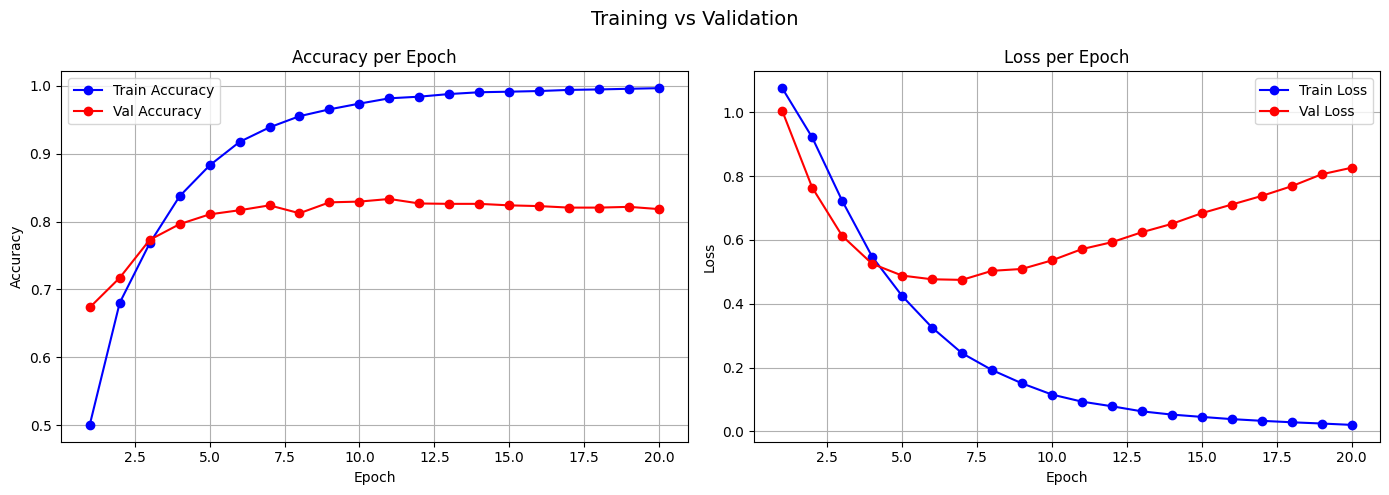

In [ ]:
import matplotlib.pyplot as plt

# Ambil data dari history
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs   = range(1, len(acc) + 1)

# Buat figure 1 baris 2 kolom
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot Accuracy ---
ax1.plot(epochs, acc, 'b-o', label='Train Accuracy')
ax1.plot(epochs, val_acc, 'r-o', label='Val Accuracy')
ax1.set_title('Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# --- Plot Loss ---
ax2.plot(epochs, loss, 'b-o', label='Train Loss')
ax2.plot(epochs, val_loss, 'r-o', label='Val Loss')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training vs Validation', fontsize=14)
plt.tight_layout()
# plt.savefig('training_plot.png', dpi=150)
plt.show()

## #6 Modeling Case 3 (Pipeline TF-IDF + SVM)


In [222]:
# perbarui pembagian dataset
text = df_filtered['text_clean'].values
label = df_filtered['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    text, label,
    test_size=0.2,       # 80/20
    random_state=42,
    stratify=y           # pastikan distribusi label seimbang di train & test
)

print(f"\nData training : {X_train.shape}")
# print(f"Data validation: {X_val.shape}")
print(f"Data testing  : {X_test.shape}")


Data training : (14454,)
Data testing  : (3614,)


In [200]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [203]:
# mencoba menggunakan optuna
import optuna
from sklearn.model_selection import cross_val_score


def objective(trial):
    # Search space TF-IDF
    max_features = trial.suggest_categorical('max_features', [5000, 10000, 20000])
    ngram_max    = trial.suggest_int('ngram_max', 1, 3)
    sublinear_tf = trial.suggest_categorical('sublinear_tf', [True, False])
    min_df       = trial.suggest_int('min_df', 1, 5)

    # Search space SVM
    C            = trial.suggest_float('C', 0.01, 100, log=True)
    kernel       = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    gamma        = trial.suggest_categorical('gamma', ['scale', 'auto']) if kernel == 'rbf' else 'scale'

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, ngram_max),
            sublinear_tf=sublinear_tf,
            min_df=min_df
        )),
        ('svm', SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            class_weight='balanced',
            random_state=42
        ))
    ])

    # 5-fold CV dengan F1 macro (lebih adil untuk imbalance)
    score = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring='f1_macro', n_jobs=-1
    ).mean()

    return score

# Jalankan optimasi — 50 trial sudah cukup untuk SVM
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("✅ Best F1 Macro :", study.best_value)
print("✅ Best Params   :", study.best_params)


[I 2026-04-23 16:32:32,112] A new study created in memory with name: no-name-8866086e-da98-4475-bfdf-3e2b69ecc45b


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-23 16:32:50,148] Trial 0 finished with value: 0.7259395737713791 and parameters: {'max_features': 10000, 'ngram_max': 1, 'sublinear_tf': True, 'min_df': 5, 'C': 20.08219758830183, 'kernel': 'linear'}. Best is trial 0 with value: 0.7259395737713791.
[I 2026-04-23 16:33:20,354] Trial 1 finished with value: 0.5750283092543531 and parameters: {'max_features': 20000, 'ngram_max': 1, 'sublinear_tf': True, 'min_df': 3, 'C': 0.031991545545344294, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.7259395737713791.
[I 2026-04-23 16:33:44,818] Trial 2 finished with value: 0.6769983357226158 and parameters: {'max_features': 20000, 'ngram_max': 3, 'sublinear_tf': False, 'min_df': 4, 'C': 0.15219670317123932, 'kernel': 'linear'}. Best is trial 0 with value: 0.7259395737713791.
[I 2026-04-23 16:34:21,481] Trial 3 finished with value: 0.15862929521199112 and parameters: {'max_features': 5000, 'ngram_max': 3, 'sublinear_tf': True, 'min_df': 4, 'C': 0.2432328046221892, 'kernel

In [223]:
best = {
    'max_features': 10000, 
    'ngram_max': 1, 
    'sublinear_tf': True, 
    'min_df': 5, 
    'C': 4.533784838559081, 
    'kernel': 'rbf', 
    'gamma': 'scale'
}

# Rebuild model dengan best params
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best['max_features'],
        ngram_range=(1, best['ngram_max']),
        sublinear_tf=best['sublinear_tf'],
        min_df=best['min_df']
    )),
    ('svm', SVC(
        kernel=best['kernel'],
        C=best['C'],
        probability=True,  
        gamma=best.get('gamma', 'scale'),
        class_weight='balanced',
        random_state=42
    ))
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred))

Testing Accuracy: 84.48%

              precision    recall  f1-score   support

     negatif       0.85      0.87      0.86      1358
      netral       0.71      0.37      0.49       389
     positif       0.85      0.92      0.89      1867

    accuracy                           0.84      3614
   macro avg       0.81      0.72      0.75      3614
weighted avg       0.84      0.84      0.83      3614



In [224]:
# simpan model SVM terbaik
import joblib
joblib.dump(best_pipeline, 'best_svm_model.joblib')

['best_svm_model.joblib']

## #7 Tesing Model

In [225]:
# model best_lstm_optuna.keras
# model best_model_cnn.keras
# model best_svm_model.joblib

from tensorflow.keras.models import load_model

lstm_model = load_model('best_lstm_optuna.keras')
cnn_model  = load_model('best_model_cnn.keras')
svm_pipeline = joblib.load('best_svm_model.joblib')

def preprocess_input(text):
    text = cleaning(text)
    text = case_folding(text)
    text = normalize_slang(text)
    text = remove_stopwords(text)
    tokens = text.split()

    return text, tokens

In [227]:
kalimat = "produk ini sangat bagus kualitasnya memuaskan dan pengiriman cepat sekali"

label_map = {0: 'negatif', 1: 'netral', 2: 'positif'}

# Preprocessing 
text_clean, tokens = preprocess_input(kalimat)
print(f"Token ({len(tokens)} kata): {tokens}\n")

# Prediksi LSTM 
seq  = tokenizer.texts_to_sequences([text_clean])
padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

lstm_proba = lstm_model.predict(padded, verbose=0)[0]
lstm_pred  = label_map[np.argmax(lstm_proba)]
print(f"🔵 LSTM   → {lstm_pred}")
print(f"   negatif: {lstm_proba[0]:.4f} | netral: {lstm_proba[1]:.4f} | positif: {lstm_proba[2]:.4f}")

# Prediksi CNN 
cnn_proba = cnn_model.predict(padded, verbose=0)[0]
cnn_pred  = label_map[np.argmax(cnn_proba)]
print(f"\n🟢 CNN    → {cnn_pred}")
print(f"   negatif: {cnn_proba[0]:.4f} | netral: {cnn_proba[1]:.4f} | positif: {cnn_proba[2]:.4f}")

# Prediksi SVM 
svm_pred   = svm_pipeline.predict([text_clean])[0]
svm_proba = svm_pipeline.predict_proba([text_clean])[0]
print(f"\n🔴 SVM    → {svm_pred}")
print(f"   negatif: {svm_proba[0]:.4f} | netral: {svm_proba[1]:.4f} | positif: {svm_proba[2]:.4f}")

Token (8 kata): ['produk', 'sangat', 'bagus', 'kualitasnya', 'memuaskan', 'pengiriman', 'cepat', 'sekali']

🔵 LSTM   → positif
   negatif: 0.0000 | netral: 0.0003 | positif: 0.9996

🟢 CNN    → positif
   negatif: 0.0000 | netral: 0.0000 | positif: 1.0000

🔴 SVM    → positif
   negatif: 0.0002 | netral: 0.0066 | positif: 0.9932


In [228]:
print("\n" + "="*45)
print(f"{'Kalimat':<10}: {kalimat}")
print("="*45)
print(f"{'Model':<10} | {'Prediksi':<10} | {'Confidence'}")
print("-"*45)
print(f"{'LSTM':<10} | {lstm_pred:<10} | {max(lstm_proba)*100:.2f}%")
print(f"{'CNN':<10} | {cnn_pred:<10} | {max(cnn_proba)*100:.2f}%")
print(f"{'SVM':<10} | {svm_pred:<10} | {max(svm_proba)*100:.2f}%")
print("="*45)


Kalimat   : produk ini sangat bagus kualitasnya memuaskan dan pengiriman cepat sekali
Model      | Prediksi   | Confidence
---------------------------------------------
LSTM       | positif    | 99.96%
CNN        | positif    | 100.00%
SVM        | positif    | 99.32%
